In [10]:
%pip install lightgbm xgboost catboost


Note: you may need to restart the kernel to use updated packages.


In [11]:
import os
import pandas as pd
import joblib


from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from src.simulator_betting import *
from src.config import *
from src.utils import get_latest_file
pd.set_option("display.max_columns", None)

In [12]:

bets_df, summary = run_season_simulation(["2022-23", "2023-24"], 
                                         min_ev=0.1 
                                        )

print("\n=== Résumé des paris ===")
print(summary)
print("\n=== Détails des paris ===")
print(bets_df.head())


=== Simulation pour la saison 2022-23 ===
Chargement du modèle existant pour 2022-23 (default)

Exemples de clés de match dans odds_df (tolérance date):
0    (2023-06-12, denver nuggets, miami heat)
1    (2023-06-09, miami heat, denver nuggets)
2    (2023-06-07, miami heat, denver nuggets)
3    (2023-06-04, denver nuggets, miami heat)
4    (2023-06-01, denver nuggets, miami heat)
Name: match_key, dtype: object

Exemples de clés de match dans nba_df:
56336     (2022-10-18, boston celtics, philadelphia 76ers)
56338    (2022-10-18, golden state warriors, los angele...
56340         (2022-10-19, detroit pistons, orlando magic)
56342     (2022-10-19, indiana pacers, washington wizards)
56344         (2022-10-19, atlanta hawks, houston rockets)
Name: match_key, dtype: object

Nombre de lignes fusionnées: 5196
Nombre de correspondances réussies: 2640
Nombre de correspondances échouées: 2556

IDs manquants TEAM_ID: []
IDs manquants OPP_TEAM_ID: []
------------------ Nombre de lignes supprimée

In [13]:
#save the bets DataFrame to a CSV file

os.makedirs(DATA_SIMULATIONS_DIR, exist_ok=True)
today = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M-%S")
bets_output_file = os.path.join(DATA_SIMULATIONS_DIR, f"bets_{today}.csv")

bets_df.to_csv(bets_output_file, index=False)

In [14]:
bets_df

,date,game_id,team,odds,prob,ev,stake,won,gain,bankroll
0,2022-10-18,22200001.0,boston celtics,1.63,0.683993,0.114908,50.000000,1,31.500000,1031.500000
1,2022-10-18,22200002.0,golden state warriors,1.28,0.804542,0.029813,51.575000,1,14.441000,1045.941000
2,2022-10-19,22200003.0,detroit pistons,1.61,0.523515,-0.157141,0.000000,1,0.000000,1045.941000
3,2022-10-19,22200004.0,indiana pacers,2.06,0.574817,0.184123,52.297050,0,-52.297050,993.643950
4,2022-10-19,22200005.0,houston rockets,4.25,0.236940,0.006996,2.138872,0,-2.138872,991.505078
...,...,...,...,...,...,...,...,...,...,...
2501,2024-04-17,52300111.0,chicago bulls,1.58,0.626701,-0.009812,0.000000,1,0.000000,1.249880
2502,2024-04-16,52300121.0,new orleans pelicans,1.77,0.631887,0.118440,0.062494,0,-0.062494,1.187386
2503,2024-04-16,52300131.0,sacramento kings,2.08,0.656667,0.365868,0.059369,1,0.064119,1.251505
2504,2024-04-19,52300201.0,miami heat,1.66,0.684102,0.135609,0.062575,1,0.041300,1.292805


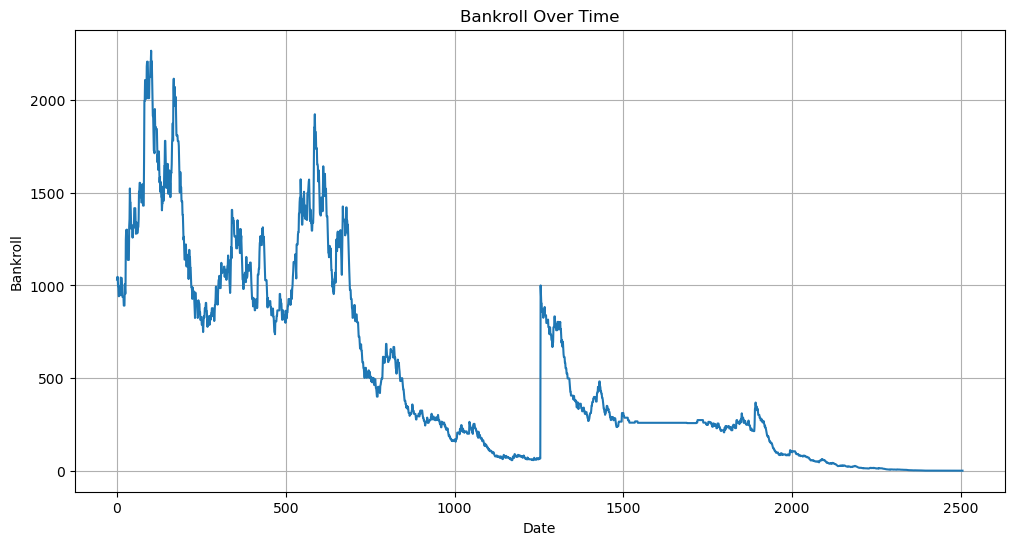

In [15]:
#plot bets_df

import matplotlib.pyplot as plt
bets_df['bankroll'].plot(kind='line', figsize=(12, 6), title='Bankroll Over Time')
plt.xlabel('Date')
plt.ylabel('Bankroll')
plt.grid()



